## imports

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

import tidy3d as td
from tidy3d.constants import C_0
from tidy3d.plugins.mode import ModeSolver

## settings

In [47]:
settings = {
    # Change this by hand
    "selected_width_um": 0.4,

    "wg_thickness_um": 0.350,

    # Frequency / wavelength sweep
    "lambda_min_nm": 1500,
    "lambda_max_nm": 1600,
    "lambda_num_points": 24,

    # Simulation domain
    "x_span_um": 10.0,
    "y_span_um": 10.0,
    "z_span_um": 0.5,

    # Grid
    "use_auto_grid": True,
    "min_steps_per_wvl": 20,

    # Mesh override
    "use_mesh_override": True,
    "mesh_override_x_extra_um": 2.0,
    "mesh_override_y_span_um": 2.0,
    "mesh_override_z_span_um": 0.5,
    "mesh_override_dl_x_um": 0.01,
    "mesh_override_dl_y_um": 0.01,
    "mesh_override_dl_z_um": 0.05,

    # Used only if use_auto_grid = False
    "uniform_grid_um": 0.1,

    # PML
    "use_custom_pml_layers": True,
    "pml_num_layers": 12,

    # We only keep fundamental, but ask for a few modes for safety
    "num_modes": 4,
}

## folders

In [48]:
root = Path.cwd().parents[1]

data_root = root / "waveguide_design" / "data" / "raw"

selected_width = settings["selected_width_um"]
run_name = datetime.now().strftime("%Y%m%d_%H%M%S")

run_dir = data_root / f"frequency_sweep_width={selected_width:.3f}um_{run_name}"

plot_dir = run_dir / "plots"
csv_dir = run_dir / "csv"

for d in [run_dir, plot_dir, csv_dir]:
    d.mkdir(parents=True, exist_ok=True)

print("Run directory:", run_dir)

Run directory: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\frequency_sweep_width=0.400um_20260502_050227


## wavelength array

In [49]:
lambda_nm_array = np.linspace(
    settings["lambda_min_nm"],
    settings["lambda_max_nm"],
    settings["lambda_num_points"],
)

lambda_um_array = lambda_nm_array / 1000

lambda_um_array[:5], lambda_um_array[-5:]

(array([1.5       , 1.50434783, 1.50869565, 1.51304348, 1.5173913 ]),
 array([1.5826087 , 1.58695652, 1.59130435, 1.59565217, 1.6       ]))

## material formulas

In [50]:
def n_sin(lambda_um):
    B1 = 2.938
    C1 = 0.13372
    D = 0.02573

    lam2 = lambda_um**2
    return np.sqrt(1 + (B1 * lam2) / (lam2 - C1**2) - D * lam2)


def n_sio2(lambda_um):
    B1 = 1.09877e6
    C1 = 92.439

    lam2 = lambda_um**2
    return np.sqrt(1 + (B1 * lam2) / (1e6 * lam2 - C1**2))

## material dispersion plot

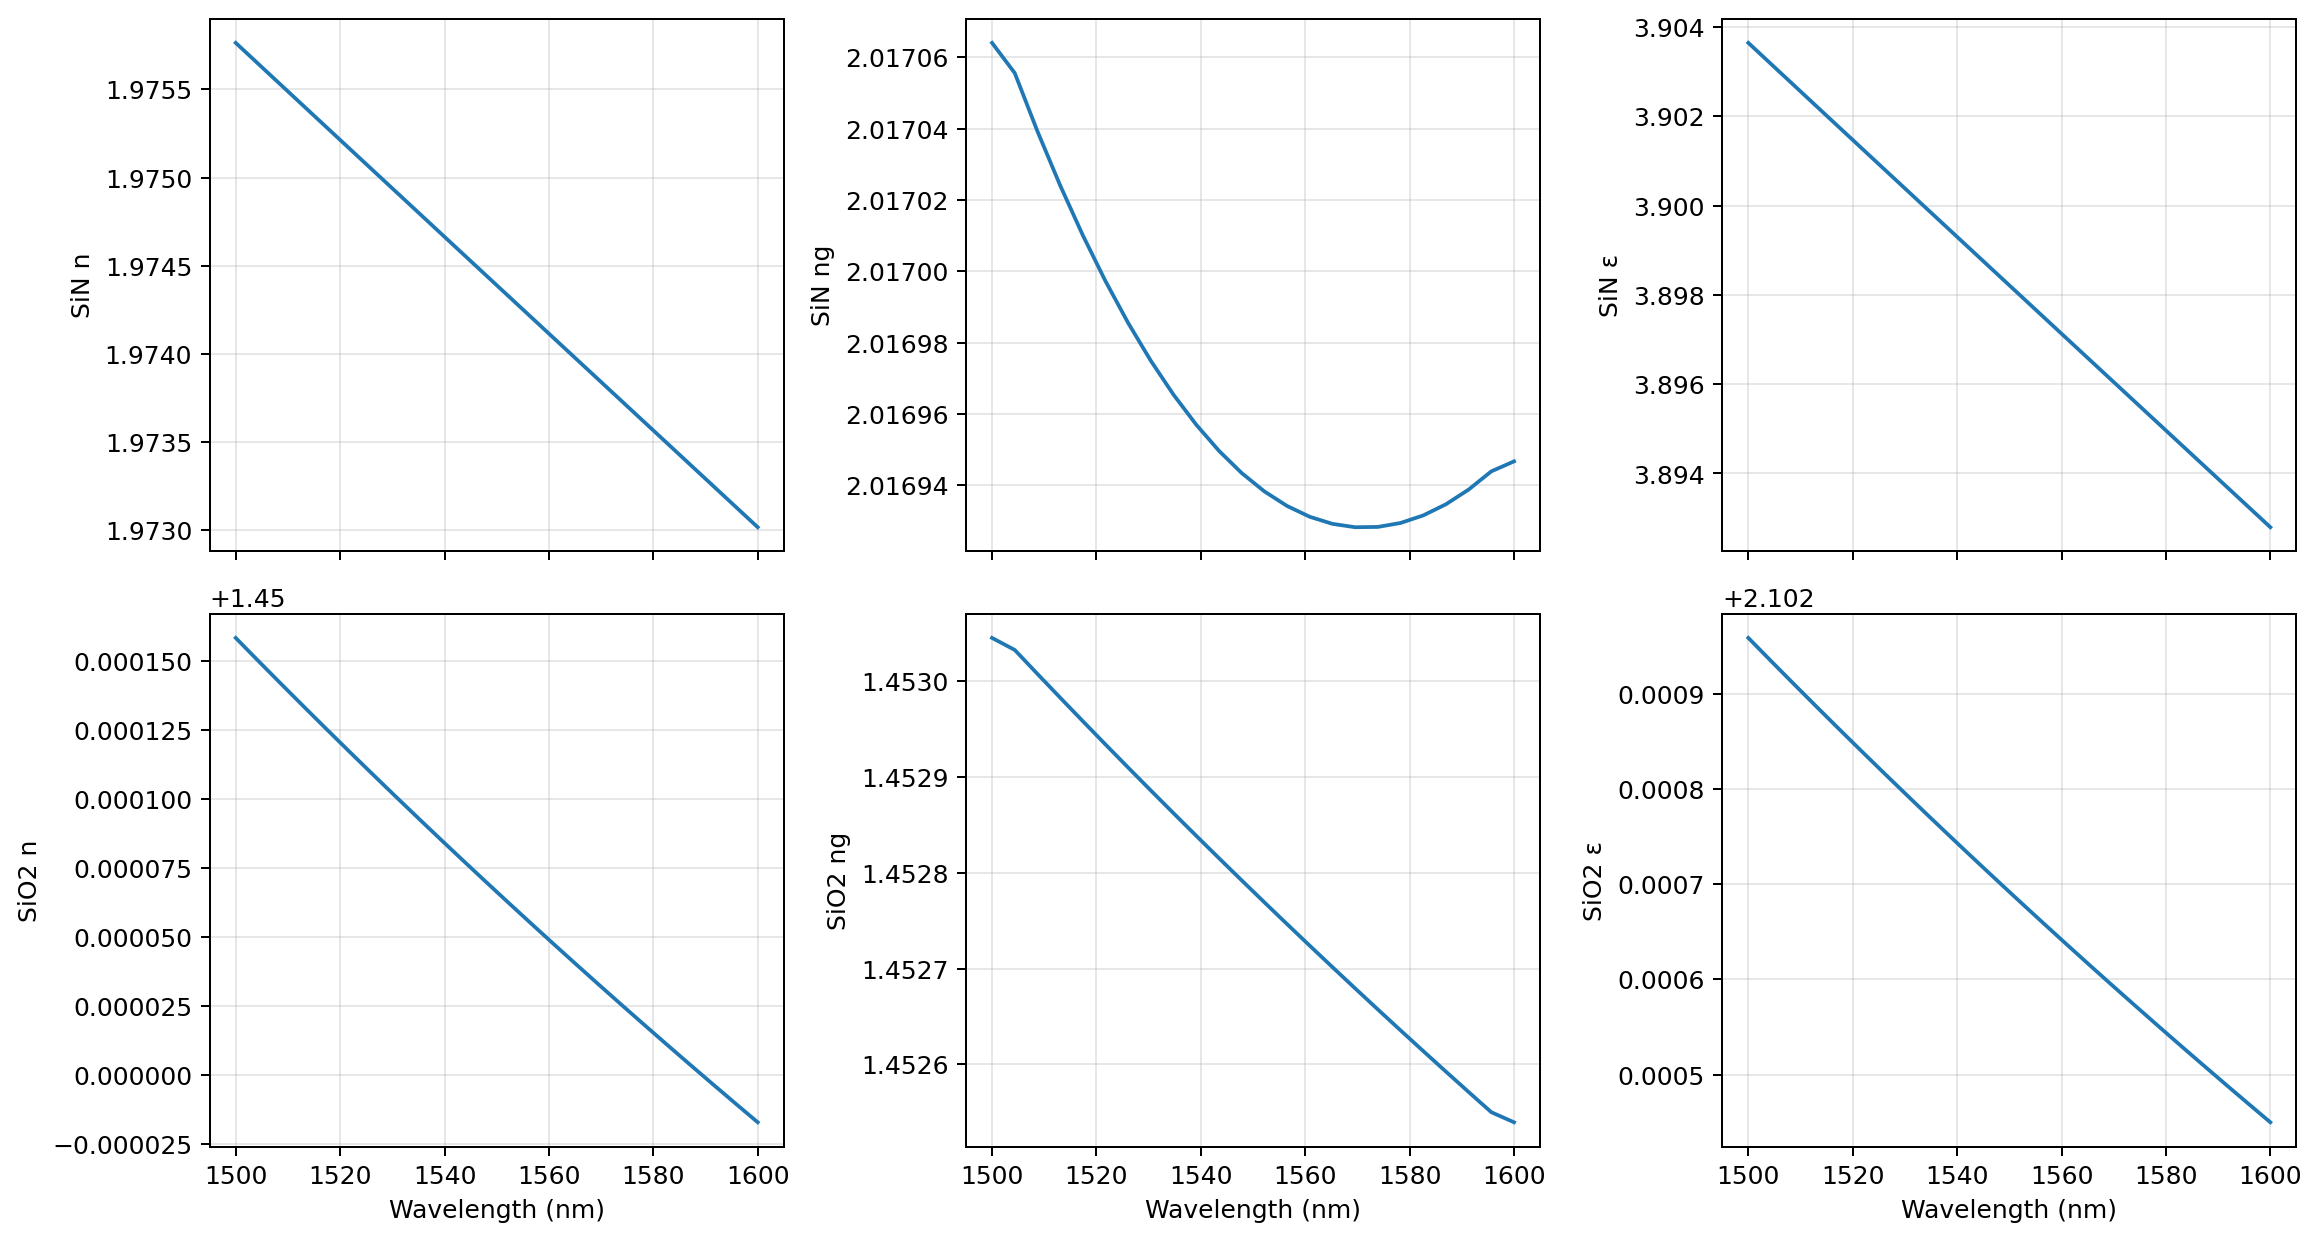

In [51]:
sin_n = n_sin(lambda_um_array)
sio2_n = n_sio2(lambda_um_array)

sin_eps = sin_n**2
sio2_eps = sio2_n**2

sin_ng = sin_n - lambda_nm_array * np.gradient(sin_n, lambda_nm_array)
sio2_ng = sio2_n - lambda_nm_array * np.gradient(sio2_n, lambda_nm_array)

fig, axes = plt.subplots(2, 3, figsize=(13, 7), dpi=180, sharex=True)

axes[0, 0].plot(lambda_nm_array, sin_n)
axes[0, 0].set_ylabel("SiN n")

axes[0, 1].plot(lambda_nm_array, sin_ng)
axes[0, 1].set_ylabel("SiN ng")

axes[0, 2].plot(lambda_nm_array, sin_eps)
axes[0, 2].set_ylabel("SiN ε")

axes[1, 0].plot(lambda_nm_array, sio2_n)
axes[1, 0].set_ylabel("SiO2 n")

axes[1, 1].plot(lambda_nm_array, sio2_ng)
axes[1, 1].set_ylabel("SiO2 ng")

axes[1, 2].plot(lambda_nm_array, sio2_eps)
axes[1, 2].set_ylabel("SiO2 ε")

for ax in axes[-1, :]:
    ax.set_xlabel("Wavelength (nm)")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(plot_dir / "materials_frequency_sweep.png", bbox_inches="tight")
plt.show()

## simulation builder for each wavelength

In [52]:
def build_simulation(width_um, lambda_um):
    wg_thick = settings["wg_thickness_um"]

    n_core = float(n_sin(lambda_um))
    n_clad = float(n_sio2(lambda_um))

    core_medium = td.Medium(permittivity=n_core**2)
    clad_medium = td.Medium(permittivity=n_clad**2)

    waveguide = td.Structure(
        geometry=td.Box(
            center=(0, 0, 0),
            size=(width_um, wg_thick, td.inf),
        ),
        medium=core_medium,
    )

    if settings["use_auto_grid"]:
        if settings["use_mesh_override"]:
            mesh_override_x_span_um = width_um + 2 * settings["mesh_override_x_extra_um"]

            grid_spec = td.GridSpec.auto(
                wavelength=lambda_um,
                min_steps_per_wvl=settings["min_steps_per_wvl"],
                override_structures=[
                    td.MeshOverrideStructure(
                        geometry=td.Box(
                            center=(0, 0, 0),
                            size=(
                                mesh_override_x_span_um,
                                settings["mesh_override_y_span_um"],
                                settings["mesh_override_z_span_um"],
                            ),
                        ),
                        dl=(
                            settings["mesh_override_dl_x_um"],
                            settings["mesh_override_dl_y_um"],
                            settings["mesh_override_dl_z_um"],
                        ),
                    )
                ],
            )
        else:
            grid_spec = td.GridSpec.auto(
                wavelength=lambda_um,
                min_steps_per_wvl=settings["min_steps_per_wvl"],
            )
    else:
        grid_spec = td.GridSpec.uniform(dl=settings["uniform_grid_um"])

    if settings["use_custom_pml_layers"]:
        boundary = td.PML(num_layers=settings["pml_num_layers"])
    else:
        boundary = td.PML()

    sim = td.Simulation(
        size=(
            settings["x_span_um"],
            settings["y_span_um"],
            settings["z_span_um"],
        ),
        grid_spec=grid_spec,
        structures=[waveguide],
        medium=clad_medium,
        boundary_spec=td.BoundarySpec.all_sides(boundary=boundary),
        run_time=1e-12,
    )

    plane = td.Box(
        center=(0, 0, 0),
        size=(
            settings["x_span_um"],
            settings["y_span_um"],
            0,
        ),
    )

    return sim, plane, n_core, n_clad

## solve one wavelength and extract fundamental mode

In [53]:
def solve_fundamental_for_lambda(width_um, lambda_um):
    freq = C_0 / lambda_um

    sim, plane, n_core, n_clad = build_simulation(width_um, lambda_um)

    mode_spec = td.ModeSpec(
        num_modes=settings["num_modes"],
        target_neff=n_core,
        group_index_step=True,
    )

    mode_solver = ModeSolver(
        simulation=sim,
        plane=plane,
        mode_spec=mode_spec,
        freqs=[freq],
    )

    mode_data = mode_solver.solve()

    neff_all = np.real(np.squeeze(mode_data.n_eff.values))

    if hasattr(mode_data, "n_group"):
        ng_all = np.real(np.squeeze(mode_data.n_group.values))
    else:
        ng_all = np.full_like(neff_all, np.nan, dtype=float)

    guided_indices = [
        i for i, neff in enumerate(neff_all)
        if neff > n_clad
    ]

    if len(guided_indices) == 0:
        return {
            "width_um": width_um,
            "wavelength_um": lambda_um,
            "wavelength_nm": lambda_um * 1000,
            "frequency_Hz": freq,
            "frequency_THz": freq / 1e12,
            "fundamental_mode_index": np.nan,
            "n_eff": np.nan,
            "n_g": np.nan,
            "n_core": n_core,
            "n_clad": n_clad,
            "is_guided": False,
        }

    # Fundamental = guided mode with maximum n_eff
    fundamental_mode_index = max(guided_indices, key=lambda i: neff_all[i])

    return {
        "width_um": width_um,
        "wavelength_um": lambda_um,
        "wavelength_nm": lambda_um * 1000,
        "frequency_Hz": freq,
        "frequency_THz": freq / 1e12,
        "fundamental_mode_index": int(fundamental_mode_index),
        "n_eff": float(neff_all[fundamental_mode_index]),
        "n_g": float(ng_all[fundamental_mode_index]),
        "n_core": float(n_core),
        "n_clad": float(n_clad),
        "is_guided": True,
    }

## main frequency sweep

In [ ]:
# ------------------------------------------------------------
# Parallel frequency sweep (fundamental mode only)
# ------------------------------------------------------------

from concurrent.futures import ThreadPoolExecutor, as_completed

selected_width_um = settings["selected_width_um"]

max_workers = 8  # start with 4–8, increase if stable

rows = []

def run_one_lambda(lambda_um):

    print("=" * 60)
    print(f"λ = {lambda_um:.4f} µm")

    row = solve_fundamental_for_lambda(
        width_um=selected_width_um,
        lambda_um=lambda_um,
    )

    print(
        f"λ = {lambda_um:.4f} µm | "
        f"n_eff = {row['n_eff']}, "
        f"guided = {row['is_guided']}"
    )

    return row


with ThreadPoolExecutor(max_workers=max_workers) as executor:

    futures = {
        executor.submit(run_one_lambda, lambda_um): lambda_um
        for lambda_um in lambda_um_array
    }

    for future in as_completed(futures):

        lambda_um = futures[future]

        try:
            row = future.result()
            rows.append(row)

        except Exception as e:
            print("=" * 60)
            print(f"FAILED λ = {lambda_um:.4f} µm")
            print(e)


# Convert to DataFrame
df_freq = pd.DataFrame(rows)

# Sort properly
df_freq = df_freq.sort_values("wavelength_um").reset_index(drop=True)

print("=" * 60)
print("Frequency sweep finished.")
print(f"Successful points: {len(df_freq)} / {len(lambda_um_array)}")

df_freq.head()

λ = 1.5000 µm
λ = 1.5043 µm
λ = 1.5087 µm
λ = 1.5130 µm
λ = 1.5174 µm
λ = 1.5217 µm
λ = 1.5261 µm
λ = 1.5304 µm


5:13:53 AM Eastern Daylight Time WARNING: Mode field at frequency index 0, mode 
                                 index 2 does not decay at the plane boundaries.

                                 WARNING: Mode field at frequency index 0, mode 
                                 index 3 does not decay at the plane boundaries.

                                 WARNING: Mode field at frequency index 1, mode 
                                 index 2 does not decay at the plane boundaries.

                                 WARNING: Mode field at frequency index 1, mode 
                                 index 3 does not decay at the plane boundaries.

...

                                 WARNING: Mode field at frequency index 1, mode 
                                 index 2 does not decay at the plane boundaries.

                                 WARNING: Mode field at frequency index 1, mode 
                                 index 3 does not decay at the plane boundaries.

                                 WARNING: Mode field at frequency index 2, mode 
                                 index 2 does not decay at the plane boundaries.

                                 WARNING: Mode field at frequency index 2, mode 
                                 index 3 does not decay at the plane boundaries.

λ = 1.5261 µm | n_eff = 1.471495017671344, guided = True
λ = 1.5652 µm


## save CSV

In [ ]:
csv_path = csv_dir / f"frequency_sweep_width_{selected_width_um:.3f}um_fundamental.csv"

df_freq.to_csv(csv_path, index=False)

print("Saved:", csv_path)
df_freq

Saved: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\frequency_sweep_width=0.600um_20260502_041826\csv\frequency_sweep_width_0.600um_fundamental.csv


,width_um,wavelength_um,wavelength_nm,frequency_Hz,frequency_THz,fundamental_mode_index,n_eff,n_g,n_core,n_clad,is_guided
0,0.6,1.500000,1500.000000,1.998616e+14,199.861639,0,1.527818,1.836151,1.975764,1.450158,True
1,0.6,1.504348,1504.347826,1.992840e+14,199.284004,0,1.526870,1.833466,1.975644,1.450150,True
2,0.6,1.508696,1508.695652,1.987097e+14,198.709698,0,1.525930,1.830778,1.975525,1.450142,True
3,0.6,1.513043,1513.043478,1.981387e+14,198.138694,0,1.524998,1.828090,1.975405,1.450133,True
4,0.6,1.517391,1517.391304,1.975710e+14,197.570961,0,1.524074,1.825400,1.975285,1.450125,True
5,0.6,1.521739,1521.739130,1.970065e+14,197.006472,0,1.523158,1.822709,1.975166,1.450117,True
6,0.6,1.526087,1526.086957,1.964452e+14,196.445200,0,1.522250,1.820017,1.975046,1.450109,True
7,0.6,1.530435,1530.434783,1.958871e+14,195.887117,0,1.521351,1.817325,1.974927,1.450101,True
8,0.6,1.534783,1534.782609,1.953322e+14,195.332196,0,1.520459,1.814633,1.974807,1.450093,True
9,0.6,1.539130,1539.130435,1.947804e+14,194.780411,0,1.519575,1.811941,1.974688,1.450085,True


## save settings

In [ ]:
settings_path = run_dir / "settings.csv"

settings_df = pd.DataFrame(
    [{"key": k, "value": v} for k, v in settings.items()]
)

settings_df.to_csv(settings_path, index=False)

print("Saved settings:", settings_path)
print("Run directory:", run_dir)

Saved settings: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\frequency_sweep_width=0.600um_20260502_041826\settings.csv
Run directory: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\frequency_sweep_width=0.600um_20260502_041826


## plot n_eff vs wavelength

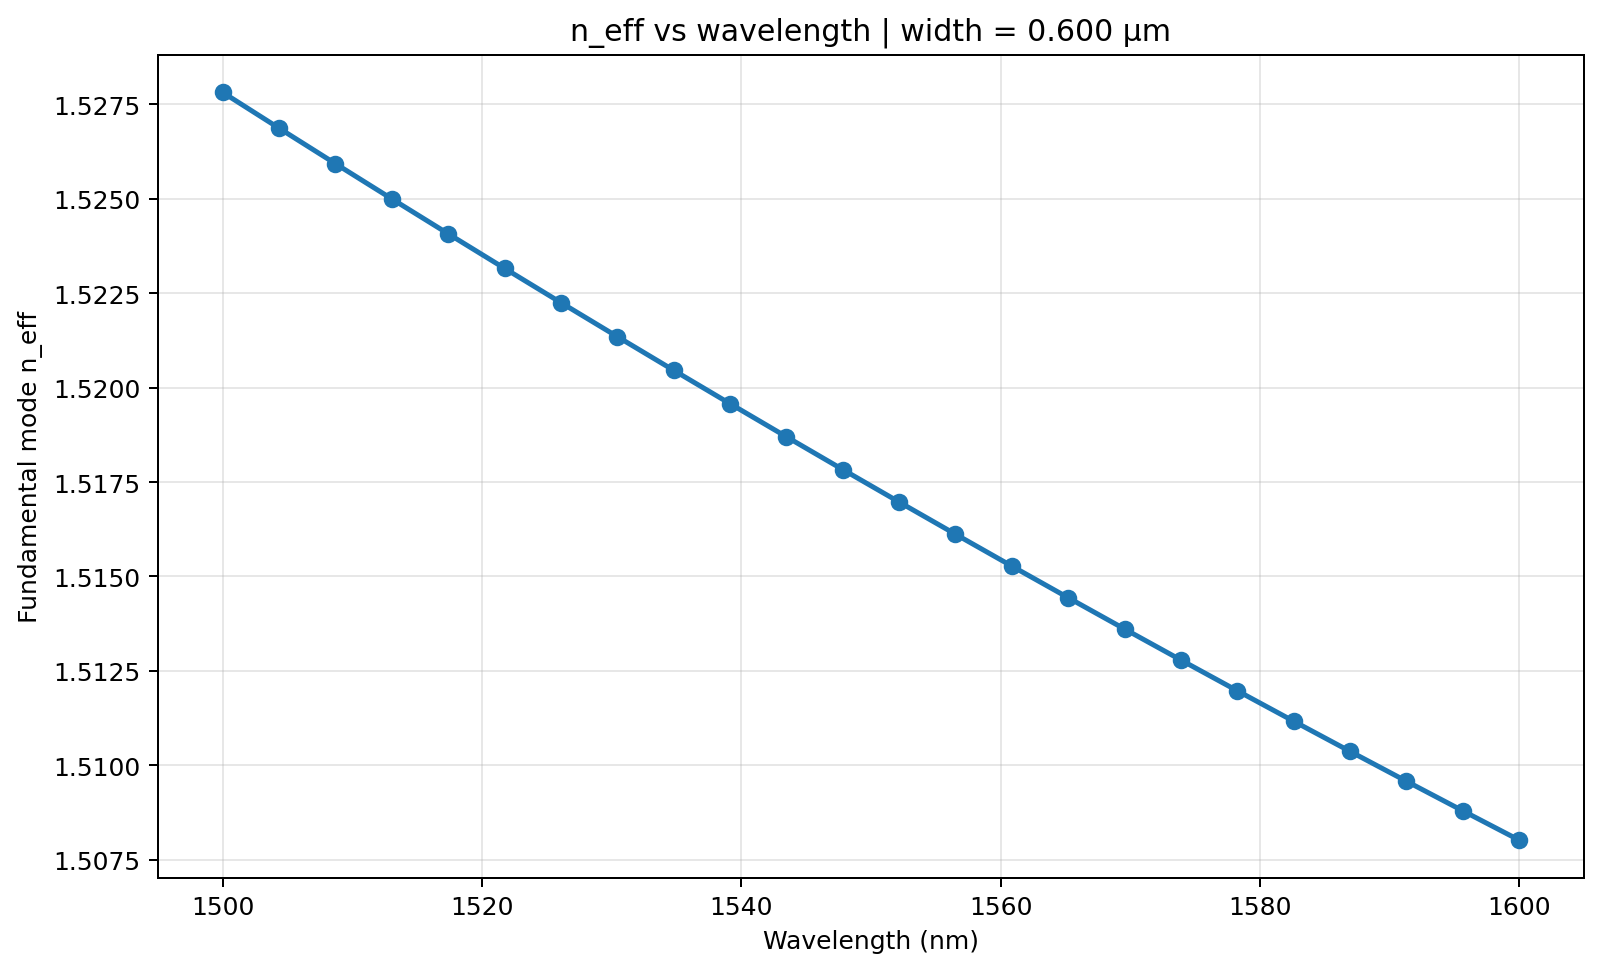

Saved: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\frequency_sweep_width=0.600um_20260502_041826\plots\neff_vs_wavelength_width_0.600um.png


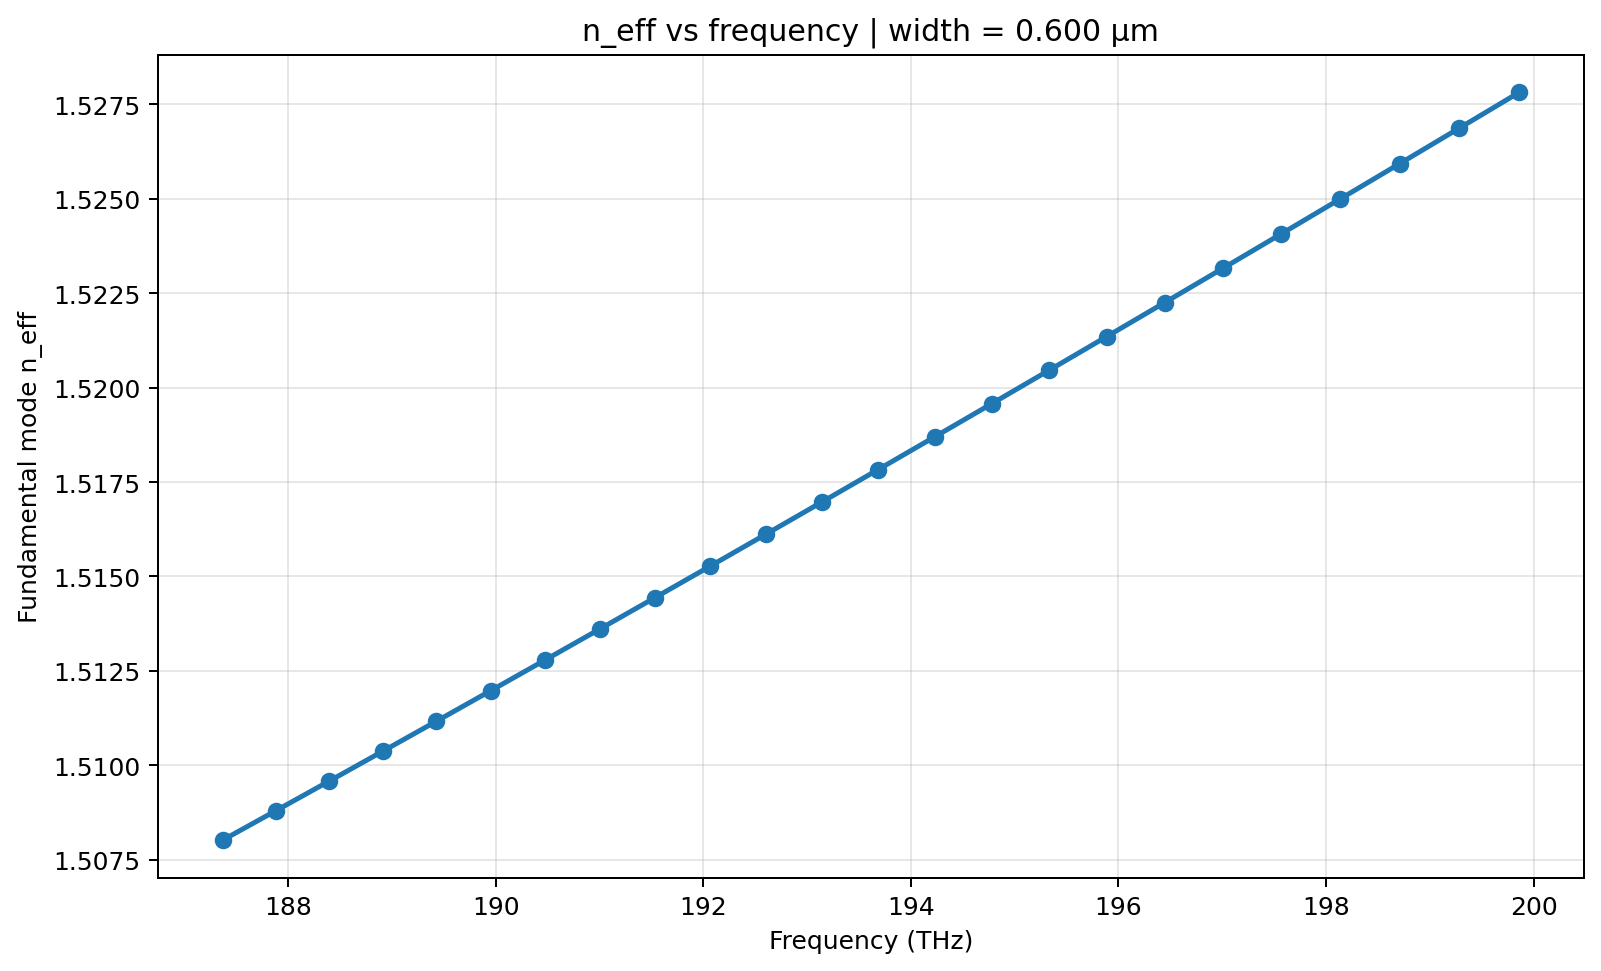

Saved: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\frequency_sweep_width=0.600um_20260502_041826\plots\neff_vs_frequency_width_0.600um.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=180)

ax.plot(
    df_freq["wavelength_nm"],
    df_freq["n_eff"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Fundamental mode n_eff")
ax.set_title(f"n_eff vs wavelength | width = {selected_width_um:.3f} µm")
ax.grid(True, alpha=0.3)

fig.tight_layout()

save_path = plot_dir / f"neff_vs_wavelength_width_{selected_width_um:.3f}um.png"
fig.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()

print("Saved:", save_path)

## plot n_eff vs frequency
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=180)

ax.plot(
    df_freq["frequency_THz"],
    df_freq["n_eff"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Fundamental mode n_eff")
ax.set_title(f"n_eff vs frequency | width = {selected_width_um:.3f} µm")
ax.grid(True, alpha=0.3)

fig.tight_layout()

save_path = plot_dir / f"neff_vs_frequency_width_{selected_width_um:.3f}um.png"
fig.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()

print("Saved:", save_path)

## quick summary

In [ ]:
print("Width:", selected_width_um, "µm")
print("Number of wavelength points:", len(df_freq))
print("CSV:", csv_path)
print("Run directory:", run_dir)

df_freq[
    [
        "width_um",
        "wavelength_nm",
        "frequency_THz",
        "n_eff",
        "n_g",
        "n_core",
        "n_clad",
        "is_guided",
    ]
].head(20)

Width: 0.6 µm
Number of wavelength points: 24
CSV: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\frequency_sweep_width=0.600um_20260502_041826\csv\frequency_sweep_width_0.600um_fundamental.csv
Run directory: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\frequency_sweep_width=0.600um_20260502_041826


,width_um,wavelength_nm,frequency_THz,n_eff,n_g,n_core,n_clad,is_guided
0,0.6,1500.000000,199.861639,1.527818,1.836151,1.975764,1.450158,True
1,0.6,1504.347826,199.284004,1.526870,1.833466,1.975644,1.450150,True
2,0.6,1508.695652,198.709698,1.525930,1.830778,1.975525,1.450142,True
3,0.6,1513.043478,198.138694,1.524998,1.828090,1.975405,1.450133,True
4,0.6,1517.391304,197.570961,1.524074,1.825400,1.975285,1.450125,True
5,0.6,1521.739130,197.006472,1.523158,1.822709,1.975166,1.450117,True
6,0.6,1526.086957,196.445200,1.522250,1.820017,1.975046,1.450109,True
7,0.6,1530.434783,195.887117,1.521351,1.817325,1.974927,1.450101,True
8,0.6,1534.782609,195.332196,1.520459,1.814633,1.974807,1.450093,True
9,0.6,1539.130435,194.780411,1.519575,1.811941,1.974688,1.450085,True
